## Testing for habitat preferences in Pangolin with hrRSF

In [1]:
%load_ext autoreload
%autoreload 2

This notebook provides a full workflow for testing certain hypotheses with respect to habitat preferences in Ground pangolin, as have been developed in the course of extensive field observations, namely:

I\ That pangolin avoid large slopes (base hypothesis to check whether the Bayesian approach is working)

II\ That pangolin prefer forest-edge structure, i.e., areas where dense bush is adjacent to more open spaces.

#### 1. Preparation

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import geopandas as gpd
from shapely import Polygon
import ee, geemap
import geemap.colormaps as cm

In [3]:
from hsa.compute import make_local_dask_client
client = make_local_dask_client(n_workers=6, threads_per_worker=2, local_directory='dask-tmp')
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 6
Total threads: 12,Total memory: 7.54 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33167,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40961,Total threads: 2
Dashboard: http://127.0.0.1:37135/status,Memory: 1.26 GiB
Nanny: tcp://127.0.0.1:40125,


In [4]:
from hsa.compute import initialize_earth_engine_on_workers
initialize_earth_engine_on_workers(client = client, project = "test-with-greta")

{'tcp://127.0.0.1:33053': True,
 'tcp://127.0.0.1:34499': True,
 'tcp://127.0.0.1:37493': True,
 'tcp://127.0.0.1:40961': True,
 'tcp://127.0.0.1:46541': True,
 'tcp://127.0.0.1:46565': True}

##### 1.1 Pangolin Relocations

In [5]:
from hsa.movement.geometry import prepare_trajectory_data
df = pd.read_csv("data/relocations/pango_subset.csv")
reloc = prepare_trajectory_data(df, geometry_col="geometry", source_crs = "EPSG:32733", target_crs = "EPSG:32733")

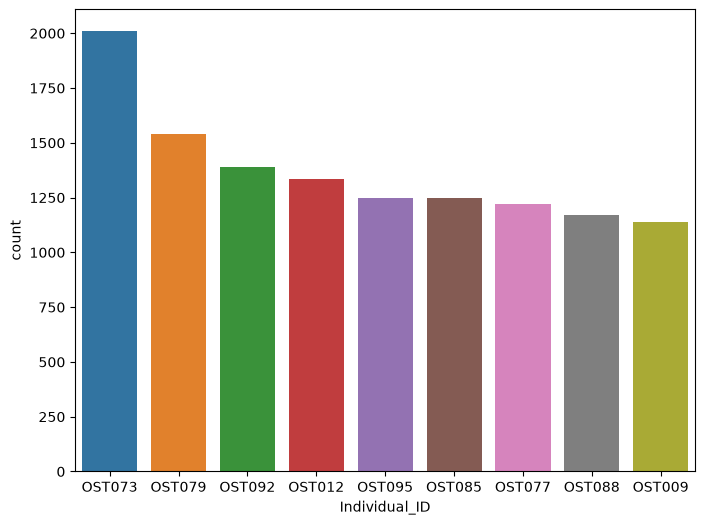

In [6]:
fig, ax = plt.subplots(figsize = (8, 6))
count_by_id = reloc.groupby("Individual_ID").size().rename("count").sort_values(ascending = False).reset_index()
sns.barplot(count_by_id, x = "Individual_ID", y = "count", hue = "Individual_ID")
plt.show()

#### 1.2 Prepare Environmental Layer

##### 1.2.1 Set-Up Remote Sensing Bench

In [13]:
EE_PROJECT = 'test-with-greta'  # change if needed
TARGET_CRS = 'EPSG:32733'
EXPORT_SCALE = 30
BUFFER_M = 0

SHAPES = Path('data/vectors')
PERIMETER_FILE = SHAPES / 'onr_perimeter.shp'
OUT_ZARR = Path('env_32733.zarr')

START = reloc["Timestamp"].min()
END = reloc["Timestamp"].max()

In [14]:
from hsa.remote_sensing import initialize_earth_engine
e = initialize_earth_engine(project=EE_PROJECT)

perimeter_raw = gpd.read_file(PERIMETER_FILE, engine='pyogrio')
perimeter = gpd.GeoDataFrame(
    geometry=[Polygon(perimeter_raw.geometry.iloc[0])],
    crs=perimeter_raw.crs,
).to_crs(TARGET_CRS)

aoi = gpd.GeoDataFrame(geometry=perimeter.geometry.buffer(BUFFER_M), crs=TARGET_CRS)
aoi_wgs84 = aoi.to_crs('EPSG:4326')
aoi_ee = geemap.geopandas_to_ee(aoi_wgs84)

def reset_map():
    Map = geemap.Map()
    Map.addLayer(aoi_ee, {}, "AOI")
    Map.centerObject(aoi_ee, zoom = 10)
    return Map

#### 1.2.2  Water mask

In [ ]:
def mask_s2_clouds(image):
    qa = image.select("QA60")

    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11

    mask = (
        qa.bitwiseAnd(cloud_bit_mask).eq(0)
        .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    )

    optical = (
        image.updateMask(mask)
        .select(
            ["B2", "B3", "B4", "B8", "B11", "B12"],
            ["blue", "green", "red", "nir", "swir1", "swir2"],
        )
        .divide(10000)
    )

    return optical.copyProperties(image, ["system:time_start"])

In [ ]:
def add_water_index(image):
    mndwi = image.normalizedDifference(["green", "swir1"]).rename("mndwi")
    return image.addBands(mndwi)

In [ ]:
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi_ee.geometry())
    .filterDate(START, END)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    .map(mask_s2_clouds)
    .map(add_water_index)
)

In [ ]:
mndwi_water = s2.select("mndwi").max().clip(aoi_ee)

Map = reset_map()
Map.addLayer(mndwi_water, {"min": 0, "max": 1, "palette": cm.palettes.Blues}, "MNDWI")
Map.addLayer(mndwi_water.gt(0.6))
Map

In [ ]:
water = mndwi_water.gt(0.6)
land_mask = water.Not()

#### 1.2.3 Acquire imagery & calculate indeces

In [ ]:
# Sentinel-1
s1 = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.eq("orbitProperties_pass", "ASCENDING"))
    .filterDate(START, END)
    .filterBounds(aoi_ee.geometry())
)

In [ ]:
# ---------------------
# Calculate S1 Indices
# ---------------------
def add_s1_indices(image):

    vv = image.select("VV")
    vh = image.select("VH")

    vv_vh_diff = vv.subtract(vh).rename("vv_vh_diff")

    vv_lin = ee.Image(10).pow(vv.divide(10)).rename("vv_linear")
    vh_lin = ee.Image(10).pow(vh.divide(10)).rename("vh_linear")

    vv_vh_ratio = vv_lin.divide(vh_lin).rename("vv_vh_ratio")

    return image.addBands([
        vv_vh_diff,
        vv_lin,
        vh_lin,
        vv_vh_ratio,
    ])

s1 = s1.map(add_s1_indices)

In [ ]:
def add_s2_indices(image):
    ndvi = image.normalizedDifference(["nir", "red"]).rename("ndvi")
    ndmi = image.normalizedDifference(["nir", "swir1"]).rename("ndmi")
    mndwi = image.normalizedDifference(["green", "swir1"]).rename("mndwi")

    bsi = (
        image.select("swir1").add(image.select("red"))
        .subtract(image.select("nir")).subtract(image.select("blue"))
        .divide(
            image.select("swir1").add(image.select("red"))
            .add(image.select("nir")).add(image.select("blue"))
        )
        .rename("bsi")
    )

    savi = (
        image.select("nir").subtract(image.select("red"))
        .multiply(1.5)
        .divide(image.select("nir").add(image.select("red")).add(0.5))
        .rename("savi")
    )

    return image.addBands([ndvi, ndmi, mndwi, bsi, savi])

s2 = s2.map(add_s2_indices)

#### 1.5 Construct the Landscape

In [ ]:
Map = reset_map()
Map

In [ ]:
vv_median = s1.select("VV").median().clip(aoi_ee)
vh_median = s1.select("VH").median().clip(aoi_ee)
vv_vh_diff_median = s1.select("vv_vh_diff").median().clip(aoi_ee)

Map.addLayer(
    ee.Image.cat([vv_median, vh_median, vv_vh_diff_median]),
    {
        "bands": ["VV", "VH", "vv_vh_diff"],
        "min": [-18, -25, 2],
        "max": [-5, -12, 12],
    },
    "S1 False Color Composite")

red = s2.select("red").median().clip(aoi_ee)
green = s2.select("green").median().clip(aoi_ee)
blue = s2.select("blue").median().clip(aoi_ee)

Map.addLayer(
    ee.Image.cat([red, green, blue]),
    {
        "bands": ["red", "green", "blue"],
        "min": 0.02,
        "max": 0.35,
    },
    "S2 True Colour Composite"
)

In [ ]:
Map.addLayer(s1.select("vv_vh_ratio").median().clip(aoi_ee), {"min": 1, "max": 8, "palette": cm.palettes.inferno}, "VV/VH")
Map.addLayer(s2.select("ndvi").median().clip(aoi_ee), {"min": 0, "max": 0.55, "palette": cm.palettes.Greens}, "NDVI")
Map.addLayer(s2.select("savi").median().clip(aoi_ee), {"min": 0, "max": 0.55, "palette": cm.palettes.Greens}, "SAVI")
Map.addLayer(s2.select("bsi").median().clip(aoi_ee), {"min": -0.5, "max": 0.5, "palette": cm.palettes.hot}, "BSI")

In [ ]:
Map

#### 1.5 Apply transformations

In [ ]:
# ------------------------------------------------------------
# SAR structural edge layer from Sentinel-1 VH
# ------------------------------------------------------------

def make_vh_edge_layers(vh, land_mask, *, smooth_radius, density_radii=(50, 100, 250)):
    vh_smooth = (
        vh.median()
        .updateMask(land_mask)
        .focal_mean(radius=smooth_radius, units="meters")
        .rename(f"vh_smooth_{smooth_radius}m")
    )

    edge = ee.Algorithms.CannyEdgeDetector(
        image=vh_smooth,
        threshold=1,
        sigma=1,
    ).rename(f"vh_edge_smooth_{smooth_radius}m")

    dist = (
        edge.fastDistanceTransform(256)
        .sqrt()
        .multiply(10)
        .rename(f"dist_to_vh_edge_smooth_{smooth_radius}m")
    )

    densities = [
        edge.unmask(0)
        .focal_mean(radius=r, units="meters")
        .rename(f"edge_density_{r}m_from_vh_smooth_{smooth_radius}m")
        for r in density_radii
    ]

    return ee.Image.cat([vh_smooth, edge, dist, *densities])

edge_stack = ee.Image.cat([
    make_vh_edge_layers(s1.select("VH"), land_mask, smooth_radius=30),
    make_vh_edge_layers(s1.select("VH"), land_mask, smooth_radius=100),
    make_vh_edge_layers(s1.select("VH"), land_mask, smooth_radius=250),
])

In [ ]:
# ------------------------------------------------------------
# Compositional layer from Sentinel-1 VH
# ------------------------------------------------------------

ndvi_30m = s2.select("ndvi").median().updateMask(land_mask).rename("ndvi_30m")

ndvi_100m = (
    s2.select("ndvi").median()
    .updateMask(land_mask)
    .focal_mean(radius=100, units="meters")
    .rename("ndvi_mean_100m")
)

ndvi_250m = (
    s2.select("ndvi").median()
    .updateMask(land_mask)
    .focal_mean(radius=250, units="meters")
    .rename("ndvi_mean_250m")
)

ndvi_stack = ee.Image.cat([ndvi_30m, ndvi_100m, ndvi_250m])

In [ ]:
# ------------------------------------------------------------
# Optical bare-ground edge layer from Sentinel-2 BSI
# ------------------------------------------------------------

PIXEL_SIZE_M = 10

def make_bsi_edge_layers(
    bsi,
    land_mask,
    *,
    smooth_radius,
    density_radii=(50, 100, 250),
    threshold=0.02,
    sigma=1,
    max_distance_pixels=256,
):
    bsi_smooth = (
        bsi
        .updateMask(land_mask)
        .focal_mean(radius=smooth_radius, units="meters")
        .rename(f"bsi_smooth_{smooth_radius}m")
    )

    bsi_edge = ee.Algorithms.CannyEdgeDetector(
        image=bsi_smooth,
        threshold=threshold,
        sigma=sigma,
    ).rename(f"bsi_edge_smooth_{smooth_radius}m")

    dist_to_bsi_edge = (
        bsi_edge
        .fastDistanceTransform(max_distance_pixels)
        .sqrt()
        .multiply(PIXEL_SIZE_M)
        .rename(f"dist_to_bsi_edge_smooth_{smooth_radius}m")
    )

    densities = [
        bsi_edge
        .unmask(0)
        .focal_mean(radius=r, units="meters")
        .rename(f"bsi_edge_density_{r}m_from_smooth_{smooth_radius}m")
        for r in density_radii
    ]

    return ee.Image.cat([
        bsi_smooth,
        bsi_edge,
        dist_to_bsi_edge,
        *densities,
    ])

bsi_base = s2.select("bsi").median().clip(aoi_ee)

bsi_edge_stack = ee.Image.cat([
    make_bsi_edge_layers(bsi_base, land_mask, smooth_radius=30),
    make_bsi_edge_layers(bsi_base, land_mask, smooth_radius=100),
    make_bsi_edge_layers(bsi_base, land_mask, smooth_radius=250),
])

In [ ]:
stack = ee.Image.cat([
    edge_stack,
    ndvi_stack,
    bsi_edge_stack
])

#### 1.2.6 Export

In [ ]:
from hsa.remote_sensing import ee_image_to_xarray_stack
from hsa.compute import suggest_xy_chunks, persist_if_dask, write_raster_stack_zarr

env = ee_image_to_xarray_stack(
    stack,
    geometry=aoi_ee.geometry(),
    crs="EPSG:32733",
    scale=100,
)

In [ ]:
env = write_raster_stack_zarr(env, "edge_ndvi_soil_32733_new.zarr")

### 2. Produce the dataset for estimation

In [7]:
from hsa.compute import open_raster_stack_zarr
from hsa.compute import suggest_xy_chunks
import xarray as xr

env = open_raster_stack_zarr("edge_ndvi_soil_32733_new.zarr")
env = env.chunk(suggest_xy_chunks(env, target_chunk_mb=256))

In [8]:
from hsa.sampling import get_availability_domain, sample_available_points, sample_raster_stack
domains = get_availability_domain(reloc, id_col="Individual_ID")
sampling = sample_available_points(domains, used = reloc, n_per_used = 10, id_col = "Individual_ID")
sampled = sample_raster_stack(sampling, env, id_cols="Individual_ID")

In [ ]:
# -------------------------
# Visual Inspection
# -------------------------

from hsa.diagnostics import inspect_sampled_use_available
res = inspect_sampled_use_available(sampled, plot = True)

In [25]:
# -------------------------
# Model comparison via AIC
# -------------------------
from hsa.rsf import compare_single_predictors, evaluate_linear_candidates_up_to_k
lk = compare_single_predictors(sampled)

In [11]:
# -------------------------
# Fitting a ML-Model
# -------------------------
from hsa.features import FeatureSpec
from hsa.rsf import fit_rsf

specs = FeatureSpec(linear = ["ndvi_30m", "vh_smooth_30m"])
model, scaler, spec, meta = fit_rsf(sampled, specs)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                   used   No. Observations:               131199
Model:                          Logit   Df Residuals:                   131196
Method:                           MLE   Df Model:                            2
Date:                Tue, 28 Jul 2026   Pseudo R-squ.:                0.002438
Time:                        09:14:19   Log-Likelihood:                -40092.
converged:                       True   LL-Null:                       -40190.
Covariance Type:            nonrobust   LLR p-value:                 2.801e-43
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.3011      0.010   -238.864      0.000      -2.320      -2.282
ndvi_30m         -0.1881      0.013    -13.962      0.000      -0.215      -0.162
vh_smooth_30m     0.1279      0.013      9.535      0.000       0.102       0.154
=================================================================================
"""

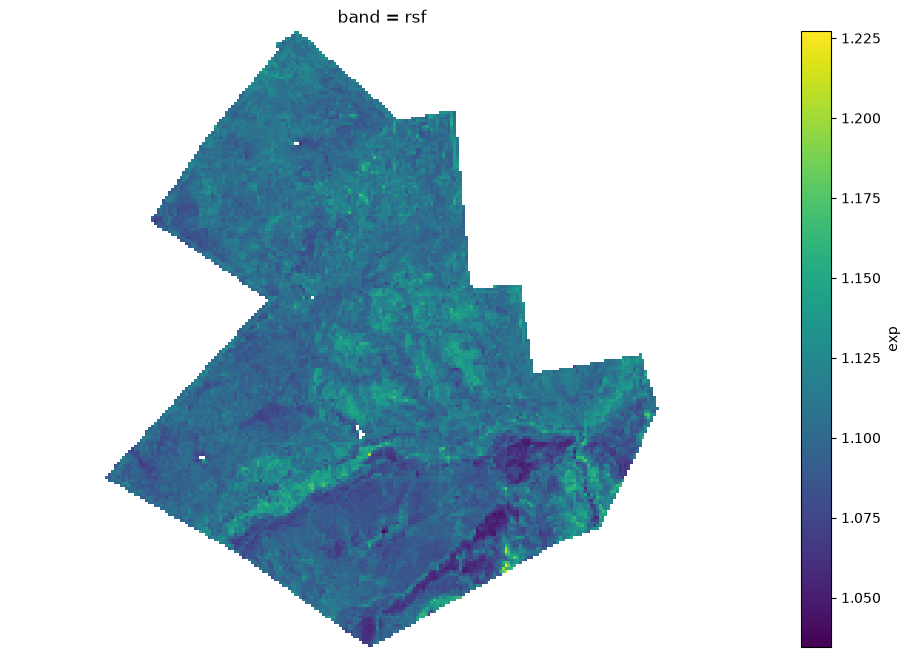

In [12]:
# -------------------------
# Fit surface
# -------------------------
import numpy as np
from hsa.rsf import predict_rsf_surface

rsf = predict_rsf_surface(env, model, scaler, spec, meta)
rsf["exp"] = np.exp(rsf)

fig, ax = plt.subplots(figsize = (12, 8))
rsf["exp"].plot(ax = ax)
ax.axis("equal")
#reloc.plot(ax = ax, color = "red", alpha = 0.01)
ax.set_axis_off()
plt.show()

In [13]:
from hsa.rsf.cv import leave_one_individual_out_rsf

specs = FeatureSpec(linear = ["ndvi_30m"])
summary, params, boyce_bins, diagnostics = leave_one_individual_out_rsf(
    reloc,
    env,
    spec,
    id_col="Individual_ID",
    heldout=["OST012"],
    sampling_factor_train=10,
    n_background_boyce=100_000,
    seed=42,
)

In [14]:
def observed_density_on_rsf_grid(
    points,
    template,
    *,
    value: float = 1.0,
):
    """Bin point counts onto the x/y grid of an RSF raster, no rasterio needed."""

    import numpy as np
    import xarray as xr

    # CRS handling if rioxarray metadata exists
    try:
        template_crs = template.rio.crs
    except Exception:
        template_crs = None

    if getattr(points, "crs", None) is not None and template_crs is not None:
        if points.crs != template_crs:
            points = points.to_crs(template_crs)

    xs = np.asarray(template["x"].values, dtype=float)
    ys = np.asarray(template["y"].values, dtype=float)

    xres = float(np.nanmedian(np.abs(np.diff(xs))))
    yres = float(np.nanmedian(np.abs(np.diff(ys))))

    x_edges = np.concatenate([
        [xs[0] - xres / 2],
        (xs[:-1] + xs[1:]) / 2,
        [xs[-1] + xres / 2],
    ])

    y_edges = np.concatenate([
        [ys[0] - yres / 2],
        (ys[:-1] + ys[1:]) / 2,
        [ys[-1] + yres / 2],
    ])

    # histogram2d needs increasing bin edges
    x_edges_sorted = np.sort(x_edges)
    y_edges_sorted = np.sort(y_edges)

    counts, _, _ = np.histogram2d(
        points.geometry.y.to_numpy(dtype=float),
        points.geometry.x.to_numpy(dtype=float),
        bins=[y_edges_sorted, x_edges_sorted],
    )

    # Re-orient to template y/x order
    if ys[0] > ys[-1]:
        counts = counts[::-1, :]

    if xs[0] > xs[-1]:
        counts = counts[:, ::-1]

    counts = counts * value

    out = xr.DataArray(
        counts.astype("float32"),
        coords={"y": template["y"], "x": template["x"]},
        dims=("y", "x"),
        name="observed_density",
    )

    if template_crs is not None:
        out = out.rio.write_crs(template_crs)

    return out

In [15]:
def make_rank_residual_map(
    rsf: xr.DataArray,
    points: gpd.GeoDataFrame,
    domain: gpd.GeoDataFrame | None = None,
    *,
    smooth_radius_cells: int | None = None,
) -> xr.DataArray:
    """Compare ranked observed point density to ranked RSF prediction.

    Positive values:
        observed use rank > RSF rank  → model underestimated use

    Negative values:
        RSF rank > observed use rank  → model overestimated use
    """

    if "band" in rsf.dims:
        rsf2 = rsf.squeeze(drop=True)
    else:
        rsf2 = rsf

    obs = observed_density_on_rsf_grid(points, rsf2)

    if smooth_radius_cells is not None and smooth_radius_cells > 0:
        obs = obs.rolling(
            x=smooth_radius_cells,
            y=smooth_radius_cells,
            center=True,
            min_periods=1,
        ).mean()

    # Optional: mask to domain
    if domain is not None:
        if domain.crs != rsf2.rio.crs:
            domain = domain.to_crs(rsf2.rio.crs)

        domain_mask = rasterize(
            [(geom, 1) for geom in domain.geometry],
            out_shape=(rsf2.sizes["y"], rsf2.sizes["x"]),
            transform=rsf2.rio.transform(),
            fill=0,
            dtype="uint8",
        ).astype(bool)

        rsf_vals = rsf2.where(domain_mask)
        obs_vals = obs.where(domain_mask)
    else:
        rsf_vals = rsf2
        obs_vals = obs

    # Rank only finite cells
    rsf_flat = rsf_vals.values.ravel()
    obs_flat = obs_vals.values.ravel()

    valid = np.isfinite(rsf_flat) & np.isfinite(obs_flat)

    rsf_rank = np.full_like(rsf_flat, np.nan, dtype="float32")
    obs_rank = np.full_like(obs_flat, np.nan, dtype="float32")

    rsf_rank[valid] = (
        pd.Series(rsf_flat[valid])
        .rank(pct=True)
        .to_numpy(dtype="float32")
    )

    obs_rank[valid] = (
        pd.Series(obs_flat[valid])
        .rank(pct=True)
        .to_numpy(dtype="float32")
    )

    residual = obs_rank - rsf_rank

    residual = residual.reshape(rsf2.sizes["y"], rsf2.sizes["x"])

    out = xr.DataArray(
        residual,
        coords={"y": rsf2["y"], "x": rsf2["x"]},
        dims=("y", "x"),
        name="rank_residual",
    ).rio.write_crs(rsf2.rio.crs)

    return out

In [16]:
import matplotlib.pyplot as plt


def plot_heldout_spatial_boyce_diagnostic(
    heldout_id,
    diagnostics: dict,
    *,
    smooth_radius_cells: int | None = 3,
    cmap: str = "RdYlBu",
    vmin: float = -1,
    vmax: float = 1,
    figsize: tuple[float, float] = (13, 5),
):
    """Plot spatial rank residuals and Boyce curve for one held-out individual."""

    d = diagnostics[heldout_id]

    rsf = d["rsf"]
    domain = d["domain"]
    points = d["test_points"]
    boyce_bins = d["boyce_bins"]

    residual = make_rank_residual_map(
        rsf,
        points,
        domain,
        smooth_radius_cells=smooth_radius_cells,
    )

    fig, axes = plt.subplots(
        ncols=2,
        figsize=figsize,
        gridspec_kw={"width_ratios": [1.2, 1]},
    )

    ax = axes[0]

    residual.plot(
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=True,
        cbar_kwargs={"label": "Observed rank - RSF rank"},
    )

    if domain.crs != residual.rio.crs:
        domain_plot = domain.to_crs(residual.rio.crs)
    else:
        domain_plot = domain

    domain_plot.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1,
    )

    xmin, ymin, xmax, ymax = domain_plot.total_bounds

    pad_x = (xmax - xmin) * 0.08
    pad_y = (ymax - ymin) * 0.08

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)
    ax.set_aspect("equal")

    pts = points
    if pts.crs != residual.rio.crs:
        pts = pts.to_crs(residual.rio.crs)

    pts.plot(
        ax=ax,
        color="black",
        markersize=4,
        alpha=0.4,
    )

    ax.set_title(f"{heldout_id}: spatial RSF rank residual")
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax = axes[1]

    curve = boyce_bins.replace([np.inf, -np.inf], np.nan).dropna(
        subset=["rsf_mid", "pe"]
    )

    ax.plot(
        curve["rsf_mid"],
        curve["pe"],
        marker="o",
        linewidth=1.5,
    )

    ax.axhline(1, linestyle="--", linewidth=1)
    ax.set_xlabel("Log RSF score")
    ax.set_ylabel("Predicted / expected ratio")
    ax.set_title("Boyce curve")

    if "boyce" in d:
        boyce_value = d["boyce"]
    elif "boyce" in boyce_bins.columns:
        boyce_value = boyce_bins["boyce"].iloc[0]
    else:
        boyce_value = np.nan

    if np.isfinite(boyce_value):
        ax.text(
            0.98,
            0.02,
            f"Boyce = {boyce_value:.3f}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
        )

    fig.tight_layout()
    return fig, axes

In [17]:
import rasterio as rio
from rasterio.features import rasterize

In [18]:
import rioxarray
from rasterio.features import rasterize

diagnostics["OST012"]["rsf"] = diagnostics["OST012"]["rsf"].rio.write_crs("EPSG:32733")

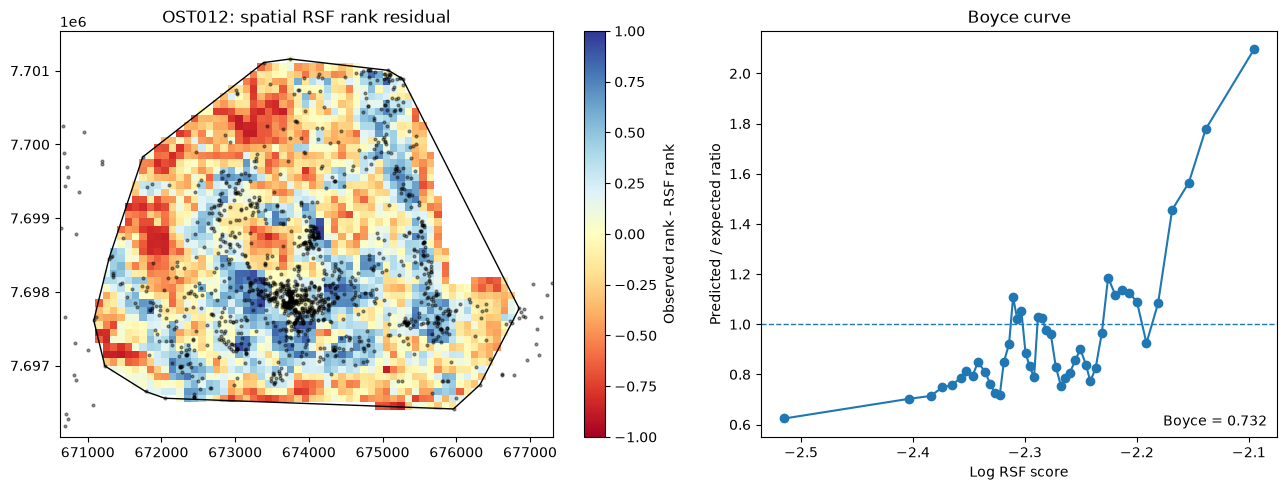

In [19]:
fig, axes = plot_heldout_spatial_boyce_diagnostic(
    "OST012",
    diagnostics,
    smooth_radius_cells=3,
)

plt.show()

In [ ]:
diag = plot_heldout_spatial_boyce_diagnostic(
    "OST012",
    diagnostics,
    smooth_radius_cells=3,
    backend="hvplot",
)

diag

In [ ]:
from hsa.rsf.validation import plot_boyce_curves
plot_boyce_curves(boyce_bins)

In [ ]:
sampled.columns

In [54]:
# -------------------------
# Bayesian Estimate
# -------------------------

import numpy as np
import pymc as pm

# Standardize
model_df = sampled[["Individual_ID", "used", "vh_smooth_30m"]].dropna(subset = "vh_smooth_30m").copy()
x_mean = model_df["vh_smooth_30m"].mean()
x_sd = model_df["vh_smooth_30m"].std()
model_df["x_z"] = (model_df["vh_smooth_30m"] - x_mean) / x_sd

# Encode individuals
individuals = np.sort(model_df["Individual_ID"].unique())
id_lookup = {ind: i for i, ind in enumerate(individuals)}
model_df["id_idx"] = model_df["Individual_ID"].map(id_lookup).astype(int)

# Arrays for PyMC
y = model_df["used"].to_numpy(dtype="int8")
x = model_df["x_z"].to_numpy(dtype="float32")
id_idx = model_df["id_idx"].to_numpy(dtype="int32")

# Build model
coords = {
    "individual": individuals,
    "obs": np.arange(len(model_df)),
}

with pm.Model(coords=coords) as edge_model:

    # Data containers
    x_data = pm.Data("x", x, dims="obs")
    id_data = pm.Data("id_idx", id_idx, dims="obs")
    y_data = pm.Data("y", y, dims="obs")

    # Population-level intercept and slope
    alpha = pm.Normal("alpha", mu=0.0, sigma=2.5)
    beta = pm.Normal("beta", mu=0.0, sigma=1.0)

    # Among-individual variation
    sigma_alpha = pm.Exponential("sigma_alpha", lam=1.0)
    sigma_beta = pm.Exponential("sigma_beta", lam=1.0)

    # Individual-level standardized deviations
    z_alpha = pm.Normal("z_alpha", mu=0.0, sigma=1.0, dims="individual")
    z_beta = pm.Normal("z_beta", mu=0.0, sigma=1.0, dims="individual")

    # Non-centered random effects
    alpha_ind = pm.Deterministic(
        "alpha_ind",
        z_alpha * sigma_alpha,
        dims="individual",
    )

    beta_ind = pm.Deterministic(
        "beta_ind",
        z_beta * sigma_beta,
        dims="individual",
    )

    # Total individual intercepts and slopes
    alpha_total = pm.Deterministic(
        "alpha_total",
        alpha + alpha_ind,
        dims="individual",
    )

    beta_total = pm.Deterministic(
        "beta_total",
        beta + beta_ind,
        dims="individual",
    )

    # Linear predictor
    eta = alpha_total[id_data] + beta_total[id_data] * x_data

    # Likelihood
    used = pm.Bernoulli(
        "used",
        logit_p=eta,
        observed=y_data,
        dims="obs",
    )

In [ ]:
with edge_model:
    idata = pm.sample(
        draws=500,
        tune=500,
        chains=2,
        cores=2,
        target_accept=0.9,
        random_seed=42,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, beta, sigma_alpha, sigma_beta, z_alpha, z_beta]


Output()

In [1]:
import arviz as az
idata = az.from_netcdf("mcmc_run.nc")

In [2]:
import arviz as az

summary = az.summary(
    idata,
    var_names=[
        "alpha",
        "beta",
        "sigma_alpha",
        "sigma_beta",
    ],
)

print(summary)

               mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat  \
alpha        -2.386  0.044     -2.5     -2.3       272       362  1.00   
beta          -0.17   0.19    -0.46      0.1       175       223  1.01   
sigma_alpha   0.123  0.042    0.074     0.21       204       270  1.00   
sigma_beta     0.56   0.16     0.38     0.84       238       280  1.01   

            mcse_mean mcse_sd  
alpha          0.0026   0.002  
beta            0.014   0.014  
sigma_alpha    0.0029  0.0029  
sigma_beta     0.0095    0.01  


In [3]:
print(az.summary(
    idata,
    var_names=["beta_total"],
    ci_prob=0.89
))

                      mean      sd eti89_lb eti89_ub  ess_bulk  ess_tail  \
beta_total[OST009]   0.872   0.038     0.81     0.93       861       904   
beta_total[OST012]   0.079   0.039    0.016     0.14      1180       762   
beta_total[OST073]  -0.789   0.044    -0.86    -0.72      1077       928   
beta_total[OST077]  -0.131   0.035    -0.19   -0.071       847       748   
beta_total[OST079]   0.058  0.0121    0.039    0.078      1005       849   
beta_total[OST085]  -0.507   0.046    -0.58    -0.44      1257       920   
beta_total[OST088]  -0.494   0.052    -0.58    -0.41      1019       799   
beta_total[OST092]  -0.249   0.033     -0.3     -0.2       915       956   
beta_total[OST095]  -0.459   0.042    -0.53    -0.39       911       804   

                   r_hat mcse_mean  mcse_sd  
beta_total[OST009]  1.00    0.0013  0.00095  
beta_total[OST012]  1.00    0.0011  0.00079  
beta_total[OST073]  1.00    0.0013  0.00089  
beta_total[OST077]  1.01    0.0012  0.00085  
beta_tota

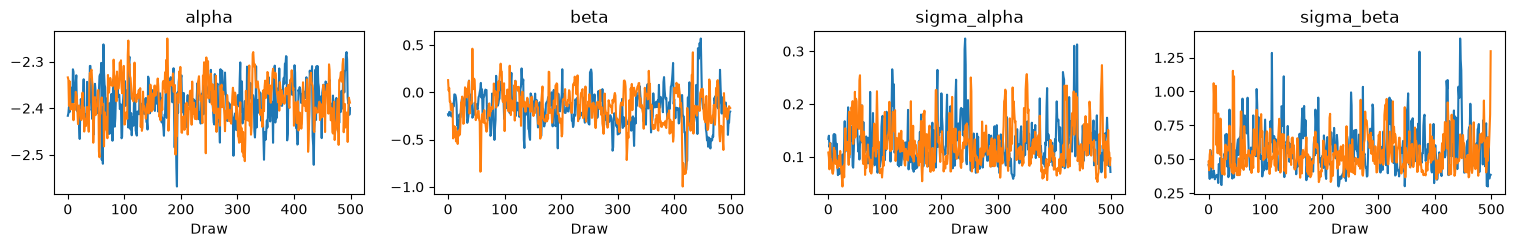

In [5]:
import matplotlib.pyplot as plt
az.plot_trace(
    idata,
    var_names=[
        "alpha",
        "beta",
        "sigma_alpha",
        "sigma_beta",
    ],
)

plt.tight_layout()
plt.show()

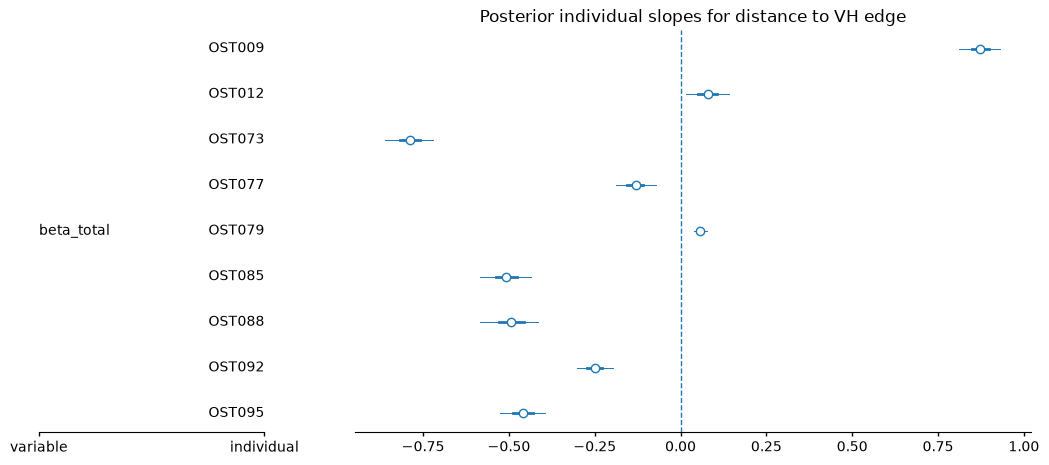

In [6]:
az.plot_forest(
    idata,
    var_names=["beta_total"],
    combined=True,
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Posterior individual slopes for distance to VH edge")
plt.show()